In [34]:
%matplotlib inline

In [2]:
import pandas as pd
import duckdb
from prefect import flow, task

In [3]:
datos = pd.read_excel(r"/workspaces/Proyecto_Aula_2/DATOS PROYECTO (1).xlsx")
datos = datos
datos = datos.astype(str)
datos.columns = [i.replace("/", "").replace("Ó", "O").replace("É", "E").replace(" ","_") for i in datos.columns]

In [3]:
#datos = datos

In [4]:
#datos = datos.astype(str)

In [3]:
datos.info()
datos.describe()

<class 'pandas.DataFrame'>
RangeIndex: 251 entries, 0 to 250
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   FECHA          251 non-null    str  
 1   EURUSD         251 non-null    str  
 2   INTERES_USA    251 non-null    str  
 3   INTERES_EUR    251 non-null    str  
 4   INFLACION_USA  251 non-null    str  
 5   INFLACION_EUR  251 non-null    str  
 6   PIB_USA        251 non-null    str  
 7   PIB_EUR        251 non-null    str  
dtypes: str(8)
memory usage: 15.8 KB


,FECHA,EURUSD,INTERES_USA,INTERES_EUR,INFLACION_USA,INFLACION_EUR,PIB_USA,PIB_EUR
count,251,251,251,251,251,251,251,251
unique,251,244,112,64,249,250,84,84
top,2005-02-01,1.3646,0.09,-0.4,0.0,0.0,12922.656,2293074.8
freq,1,2,20,41,3,2,3,3


In [4]:
[i.replace("/", "").replace("Ó", "O").replace("É", "E").replace(" ","_") for i in datos.columns]

['FECHA',
 'EURUSD',
 'INTERES_USA',
 'INTERES_EUR',
 'INFLACION_USA',
 'INFLACION_EUR',
 'PIB_USA',
 'PIB_EUR']

In [7]:
#datos.info()

In [13]:
@task
def cargar_datos():

    df = pd.read_excel("/workspaces/Proyecto_Aula_2/DATOS PROYECTO (1).xlsx")

    df.columns = [
        'FECHA',
        'EURUSD',
        'INTERES_USA',
        'INTERES_EUR',
        'INFLACION_USA',
        'INFLACION_EUR',
        'PIB_USA',
        'PIB_EUR'
    ]

    return df

In [14]:
@task
def crear_esquemas():

    con = duckdb.connect("proyectolassupernenas.duckdb")

    con.execute("CREATE SCHEMA IF NOT EXISTS proyectolassupernenas.bronze")
    con.execute("CREATE SCHEMA IF NOT EXISTS proyectolassupernenas.silver")
    con.execute("CREATE SCHEMA IF NOT EXISTS proyectolassupernenas.gold")

In [15]:
@task
def bronze(df):

    con = duckdb.connect("proyectolassupernenas.duckdb")

    con.execute("""
    CREATE OR REPLACE TABLE proyectolassupernenas.bronze.precios AS
    SELECT * FROM df
    """)

In [16]:
@task
def silver():

    con = duckdb.connect("proyectolassupernenas.duckdb")

    con.execute("""
    CREATE OR REPLACE TABLE proyectolassupernenas.silver.precios AS
    SELECT
    *,
    CAST(EURUSD AS FLOAT) AS EURUSD_F,
    CAST(INTERES_USA AS FLOAT) AS INTERES_USA_F,
    CAST(INTERES_EUR AS FLOAT) AS INTERES_EUR_F,
    CAST(INFLACION_USA AS FLOAT) AS INFLACION_USA_F,
    CAST(INFLACION_EUR AS FLOAT) AS INFLACION_EUR_F,
    CAST(PIB_USA AS FLOAT) AS PIB_USA_F,
    CAST(PIB_EUR AS FLOAT) AS PIB_EUR_F,
    CAST(FECHA AS DATE) AS FECHA_F
FROM proyectolassupernenas.bronze.precios
""")

In [23]:
@task
def gold():

    con = duckdb.connect("proyectolassupernenas.duckdb")

    con.execute("""
    CREATE OR REPLACE TABLE proyectolassupernenas.gold.modelo AS
    SELECT
    *,

    (INTERES_USA_F - INTERES_EUR_F) AS DIF_INTERES,

    (INFLACION_USA_F - INFLACION_EUR_F) AS DIF_INFLACION,

    (PIB_USA_F - PIB_EUR_F) AS DIF_PIB

FROM proyectolassupernenas.silver.precios
""")

In [24]:
@task
def analisis():

    con = duckdb.connect("proyectolassupernenas.duckdb")

    df = con.execute("""
    SELECT * FROM proyectolassupernenas.gold.modelo
    """).df()

    print(df.describe())

In [35]:
@task
def visualizacion():

    import matplotlib.pyplot as plt

    con = duckdb.connect("proyectolassupernenas.duckdb")

    df = con.execute("""
    SELECT * FROM proyectolassupernenas.gold.modelo
    """).df()

    plt.figure(figsize=(10,5))
    plt.plot(df["FECHA_F"], df["EURUSD_F"])
    plt.title("Comportamiento EUR/USD")
    plt.xticks(rotation=45)
    plt.show()

In [31]:
@flow
def flujo_de_tareas():

    crear_esquemas()

    df = cargar_datos()

    bronze(df)

    silver()

    gold()

    analisis()

    visualizacion()

00:29:47.072 | INFO    | Flow run 'exuberant-kakapo' - Beginning flow run 'exuberant-kakapo' for flow 'flujo-de-tareas'

00:29:47.074 | INFO    | Flow run 'exuberant-kakapo' - View at https://app.prefect.cloud/account/57ae3166-d87a-4de2-8607-dd788bfe6ff8/workspace/c3407c74-a61b-49ca-97c0-3701378b812d/runs/flow-run/06a05177-aa99-78cc-8000-3828ace74aaa

00:29:47.082 | INFO    | Task run 'crear_esquemas-bf8' - Finished in state Completed()

00:29:47.109 | INFO    | Task run 'cargar_datos-96d' - Finished in state Completed()

00:29:47.122 | INFO    | Task run 'bronze-db2' - Finished in state Completed()

00:29:47.133 | INFO    | Task run 'silver-b33' - Finished in state Completed()

00:29:47.144 | INFO    | Task run 'gold-1a9' - Finished in state Completed()

                            FECHA      EURUSD  INTERES_USA  INTERES_EUR  \
count                         251  251.000000   251.000000   251.000000   
mean   2015-07-02 01:20:19.123506    1.224317     1.804582     0.781952   
min           2005-02-01 00:00:00    0.985300     0.050000    -0.500000   
25%           2010-04-16 00:00:00    1.113150     0.120000    -0.400000   
50%           2015-07-01 00:00:00    1.196500     0.660000     0.250000   
75%           2020-09-16 00:00:00    1.322950     3.830000     2.000000   
max           2025-12-01 00:00:00    1.575900     5.330000     4.000000   
std                           NaN    0.130529     1.976372     1.415974   

       INFLACION_USA  INFLACION_EUR       PIB_USA       PIB_EUR    EURUSD_F  \
count     251.000000     251.000000    251.000000  2.510000e+02  251.000000   
mean        0.002125       0.001776  19544.470195  2.555594e+06    1.224317   
min        -0.017705      -0.015434  12527.214000  2.273045e+06    0.985300   
25%     

00:29:47.185 | INFO    | Task run 'analisis-8e4' - Finished in state Completed()

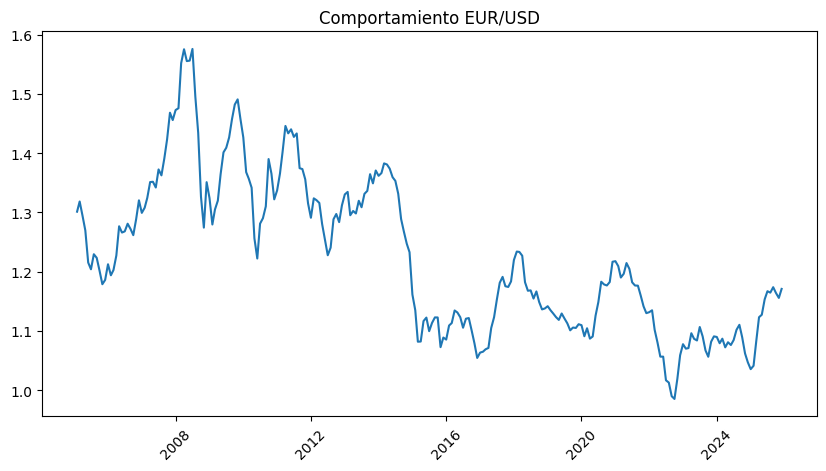

00:29:49.460 | INFO    | Task run 'visualizacion-042' - Finished in state Completed()

00:29:50.133 | INFO    | Flow run 'exuberant-kakapo' - Finished in state Completed()

In [32]:
flujo_de_tareas()

Codigo bien

In [27]:
import duckdb

con = duckdb.connect("proyectolassupernenas.duckdb")

df = con.execute("""
SELECT * 
FROM proyectolassupernenas.gold.modelo
""").df()

df.head()

,FECHA,EURUSD,INTERES_USA,INTERES_EUR,INFLACION_USA,INFLACION_EUR,PIB_USA,PIB_EUR,EURUSD_F,INTERES_USA_F,INTERES_EUR_F,INFLACION_USA_F,INFLACION_EUR_F,PIB_USA_F,PIB_EUR_F,FECHA_F,DIF_INTERES,DIF_INFLACION,DIF_PIB
0,2005-02-01,1.3013,2.50,1.0,0.004175,0.003606,12527.214,2273045.3,1.3013,2.50,1.0,0.004175,0.003606,12527.213867,2273045.25,2005-02-01,1.50,0.000570,-2260518.0
1,2005-03-01,1.3185,2.63,1.0,0.003638,0.007425,12527.214,2273045.3,1.3185,2.63,1.0,0.003638,0.007425,12527.213867,2273045.25,2005-03-01,1.63,-0.003787,-2260518.0
2,2005-04-01,1.2943,2.79,1.0,0.003107,0.004161,12922.656,2293074.8,1.2943,2.79,1.0,0.003107,0.004161,12922.656250,2293074.75,2005-04-01,1.79,-0.001054,-2280152.0
3,2005-05-01,1.2697,3.00,1.0,-0.000516,0.002249,12922.656,2293074.8,1.2697,3.00,1.0,-0.000516,0.002249,12922.656250,2293074.75,2005-05-01,2.00,-0.002766,-2280152.0
4,2005-06-01,1.2155,3.04,1.0,0.000517,0.001063,12922.656,2293074.8,1.2155,3.04,1.0,0.000517,0.001063,12922.656250,2293074.75,2005-06-01,2.04,-0.000547,-2280152.0


In [29]:
df[['EURUSD_F','DIF_INTERES','DIF_INFLACION','DIF_PIB']].corr()

,EURUSD_F,DIF_INTERES,DIF_INFLACION,DIF_PIB
EURUSD_F,1.000000,-0.482197,0.043930,0.673417
DIF_INTERES,-0.482197,1.000000,0.057003,-0.360734
DIF_INFLACION,0.043930,0.057003,1.000000,-0.015388
DIF_PIB,0.673417,-0.360734,-0.015388,1.000000


In [1]:
import streamlit as st

st.title("Proyecto EUR/USD")

st.write("Dashboard de análisis macroeconómico")

2026-05-14 14:32:19.258 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-14 14:32:19.399 
  command:

    streamlit run /workspaces/Proyecto_Aula_2/.venv/lib/python3.12/site-packages/ipykernel_launcher.py [ARGUMENTS]
2026-05-14 14:32:19.399 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-14 14:32:19.400 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-14 14:32:19.401 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-14 14:32:19.401 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-14 14:32:19.401 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
